In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pyexpat import features

from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../PythonProject/Testing data/TSLA.csv')

In [4]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,29-06-2010,3.800,5.000,3.508,4.778,4.778,93831500
1,30-06-2010,5.158,6.084,4.660,4.766,4.766,85935500
2,01-07-2010,5.000,5.184,4.054,4.392,4.392,41094000
3,02-07-2010,4.600,4.620,3.742,3.840,3.840,25699000
4,06-07-2010,4.000,4.000,3.166,3.222,3.222,34334500


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03
mean,138.691296,141.771603,135.425953,138.762183,138.762183,3.131449e+07
std,250.044839,255.863239,243.774157,250.123115,250.123115,2.798383e+07
min,3.228000,3.326000,2.996000,3.160000,3.160000,5.925000e+05
25%,19.627000,20.402000,19.127500,19.615000,19.615000,1.310288e+07
50%,46.656999,47.487001,45.820002,46.545000,46.545000,2.488680e+07
75%,68.057001,69.357500,66.911501,68.103998,68.103998,3.973875e+07
max,1234.410034,1243.489990,1217.000000,1229.910034,1229.910034,3.046940e+08


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   str    
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 161.8 KB


In [7]:
df[df['Close']==df['Adj Close']].shape

(2956, 7)

In [8]:
#Exploratory Data Analysis

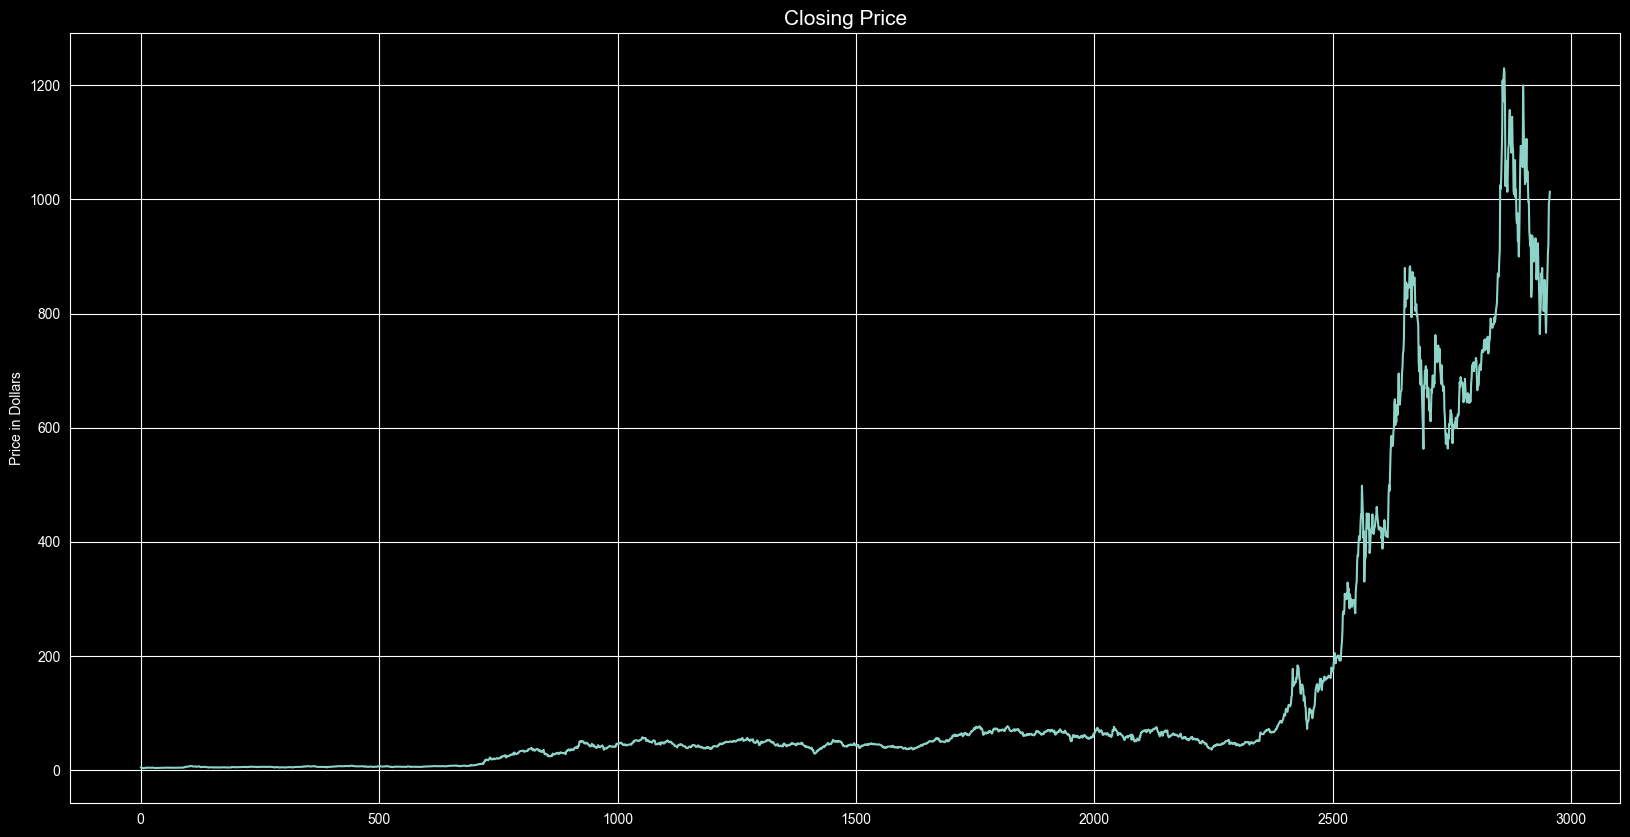

In [9]:
plt.figure(figsize=(20,10))
plt.plot(df['Close'])
plt.title('Closing Price',fontsize=15)
plt.ylabel('Price in Dollars')
plt.show()

In [10]:
df = df.drop(['Adj Close'], axis=1)

In [11]:
df.head()

,Date,Open,High,Low,Close,Volume
0,29-06-2010,3.800,5.000,3.508,4.778,93831500
1,30-06-2010,5.158,6.084,4.660,4.766,85935500
2,01-07-2010,5.000,5.184,4.054,4.392,41094000
3,02-07-2010,4.600,4.620,3.742,3.840,25699000
4,06-07-2010,4.000,4.000,3.166,3.222,34334500


In [12]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

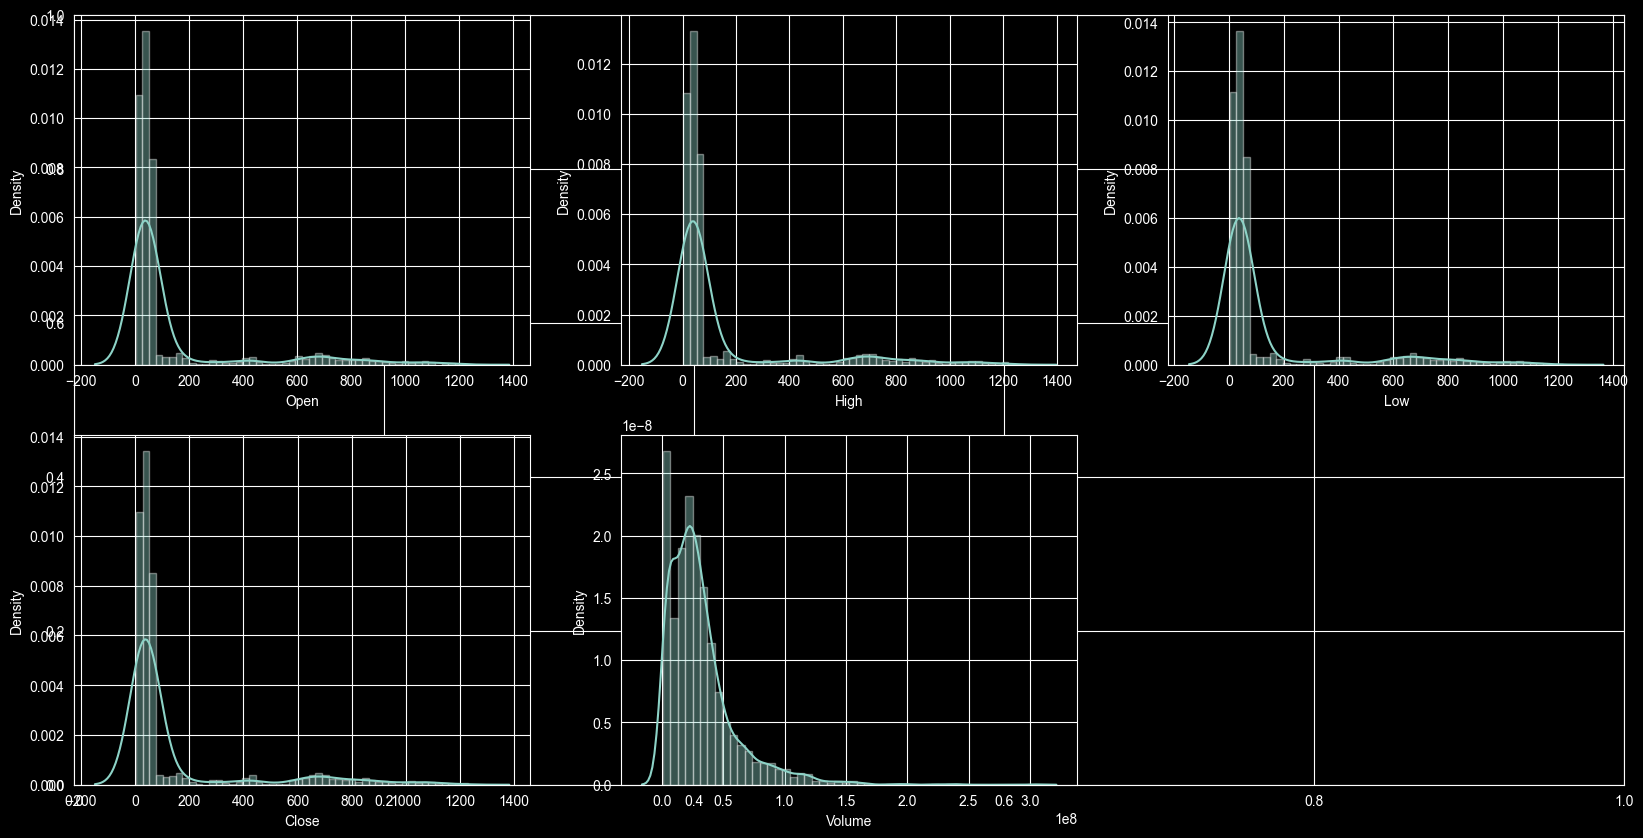

In [13]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))
for i,col in enumerate(features):
    plt.subplot(2,3,i+1)
    sb.distplot(df[col])
plt.show()

In [14]:
df.head()

,Date,Open,High,Low,Close,Volume
0,29-06-2010,3.800,5.000,3.508,4.778,93831500
1,30-06-2010,5.158,6.084,4.660,4.766,85935500
2,01-07-2010,5.000,5.184,4.054,4.392,41094000
3,02-07-2010,4.600,4.620,3.742,3.840,25699000
4,06-07-2010,4.000,4.000,3.166,3.222,34334500


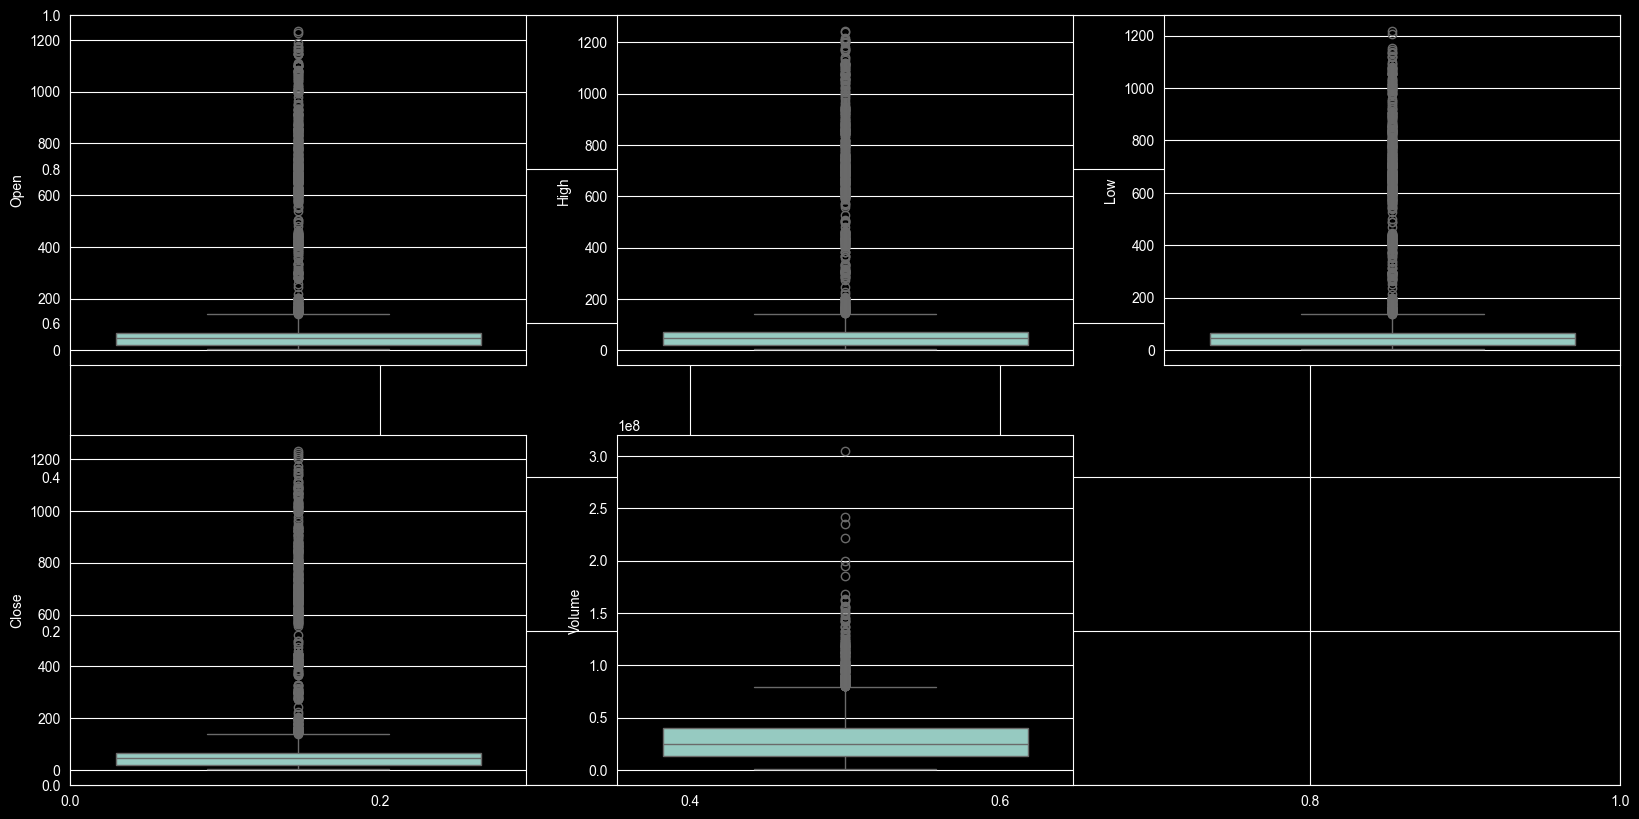

In [15]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
    plt.subplot(2,3,i+1)
    sb.boxplot(df[col])
plt.show()

In [16]:
splitted = df['Date'].str.split('-', expand=True)

df['day'] = splitted[0].astype(int)
df['month'] = splitted[1].astype(int)
df['year'] = splitted[2].astype(int)


In [17]:
df.head()

,Date,Open,High,Low,Close,Volume,day,month,year
0,29-06-2010,3.800,5.000,3.508,4.778,93831500,29,6,2010
1,30-06-2010,5.158,6.084,4.660,4.766,85935500,30,6,2010
2,01-07-2010,5.000,5.184,4.054,4.392,41094000,1,7,2010
3,02-07-2010,4.600,4.620,3.742,3.840,25699000,2,7,2010
4,06-07-2010,4.000,4.000,3.166,3.222,34334500,6,7,2010


In [18]:
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df.head()

,Date,Open,High,Low,Close,Volume,day,month,year,is_quarter_end
0,29-06-2010,3.800,5.000,3.508,4.778,93831500,29,6,2010,1
1,30-06-2010,5.158,6.084,4.660,4.766,85935500,30,6,2010,1
2,01-07-2010,5.000,5.184,4.054,4.392,41094000,1,7,2010,0
3,02-07-2010,4.600,4.620,3.742,3.840,25699000,2,7,2010,0
4,06-07-2010,4.000,4.000,3.166,3.222,34334500,6,7,2010,0


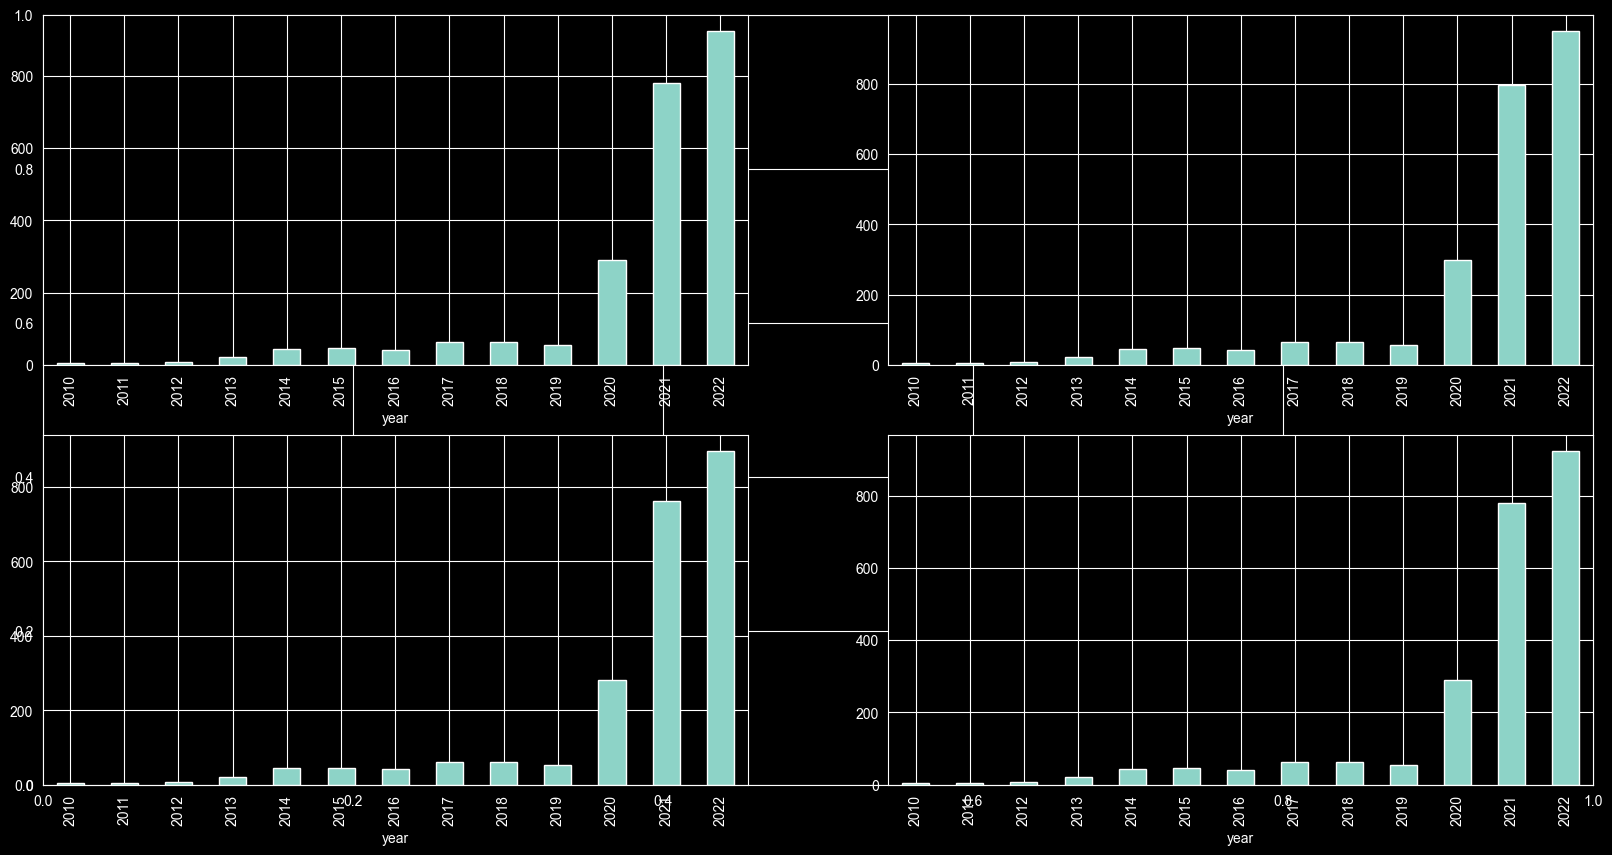

In [19]:
data_grouped = df.drop('Date', axis=1).groupby('year').mean()
plt.subplots(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()

# This code is modified by Susobhan Akhuli

In [20]:
df.drop('Date', axis=1).groupby('is_quarter_end').mean()

,Open,High,Low,Close,Volume,day,month,year
is_quarter_end,,,,,,,,
0,136.474690,139.523037,133.361644,136.531872,3.194378e+07,15.701987,6.124300,2015.855833
1,143.073168,146.216652,139.506757,143.171146,3.007048e+07,15.736153,7.489426,2015.852971


In [21]:
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

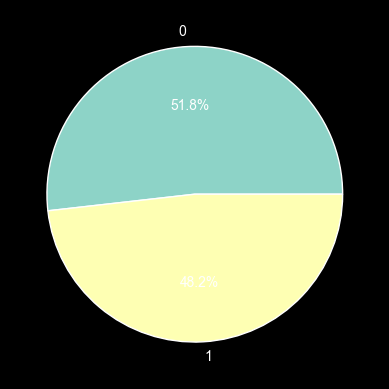

In [22]:
plt.pie(df['target'].value_counts().values,
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

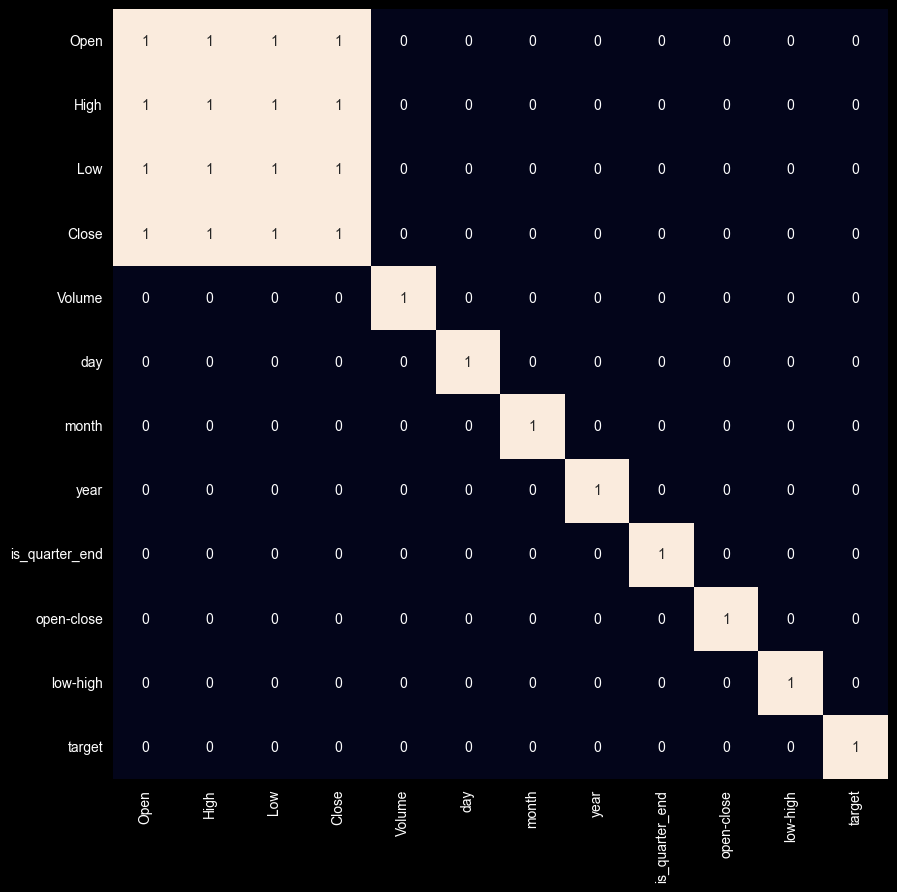

In [23]:
plt.figure(figsize=(10, 10))

# As our concern is with the highly
# correlated features only so, we will visualize
# our heatmap as per that criteria only.
sb.heatmap(df.drop('Date', axis=1).corr() > 0.9, annot=True, cbar=False)
plt.show()


In [24]:
features = df[['open-close', 'low-high', 'is_quarter_end']]
target = df['target']

scaler = StandardScaler()
features = scaler.fit_transform(features)

X_train, X_valid, Y_train, Y_valid = train_test_split(
    features, target, test_size=0.1, random_state=2022)
print(X_train.shape, X_valid.shape)

(2660, 3) (296, 3)


In [25]:
models = [LogisticRegression(), SVC(
  kernel='poly', probability=True), XGBClassifier()]

for i in range(3):
  models[i].fit(X_train, Y_train)

  print(f'{models[i]} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(
    Y_train, models[i].predict_proba(X_train)[:,1]))
  print('Validation Accuracy : ', metrics.roc_auc_score(
    Y_valid, models[i].predict_proba(X_valid)[:,1]))
  print()

LogisticRegression() : 
Training Accuracy :  0.5145097983728333
Validation Accuracy :  0.5385531135531135

SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.5003673151750974
Validation Accuracy :  0.4596611721611722

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Traini

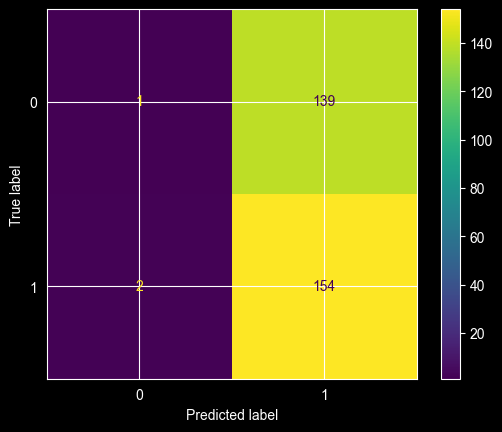

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(models[0], X_valid, Y_valid)
plt.show()


In [27]:
"We can observe that the accuracy achieved by the state-of-the-art ML model is no better than simply guessing with a probability of 50%. Possible reasons for this may be the lack of data or using a very simple model to perform such a complex task as Stock Market prediction."



'We can observe that the accuracy achieved by the state-of-the-art ML model is no better than simply guessing with a probability of 50%. Possible reasons for this may be the lack of data or using a very simple model to perform such a complex task as Stock Market prediction.'